# XGBoost with VGG16 for Image Classification

## Setup

In [36]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

import tensorflow as tf
from PIL import Image
import cv2

from sklearn import preprocessing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

import xgboost
from xgboost import XGBClassifier

## Data Loading & Preprocessing

In [37]:
# Define paths and image size
IMG_SIZE = (224, 224)
TRAINING_DIR = '/home/vineet/Downloads/XGBoost/brain-mri/Training'
VALIDATION_DIR = '/home/vineet/Downloads/XGBoost/brain-mri/Validation'
TESTING_DIR = '/home/vineet/Downloads/XGBoost/brain-mri/Testing'

def load_images(directory):
    """Load images from directory and return arrays of images and labels."""
    images = []
    labels = []
    
    for class_dir in glob.glob(os.path.join(directory, '*')):
        label = os.path.basename(class_dir)
        
        for img_path in glob.glob(os.path.join(class_dir, '*')):
            if img_path.startswith('.'):
                continue
            
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            img = cv2.resize(img, IMG_SIZE)
            images.append(img)
            labels.append(label)
    
    return np.array(images), np.array(labels)

# Load all datasets
print("Loading datasets...")
train_images, train_labels = load_images(TRAINING_DIR)
val_images, val_labels = load_images(VALIDATION_DIR)
test_images, test_labels = load_images(TESTING_DIR)

print(f"✓ Training set: {train_images.shape}")
print(f"✓ Validation set: {val_images.shape}")
print(f"✓ Testing set: {test_images.shape}")

Loading datasets...
✓ Training set: (946, 224, 224, 3)
✓ Validation set: (1924, 224, 224, 3)
✓ Testing set: (394, 224, 224, 3)


## Encode Labels

In [38]:
le = preprocessing.LabelEncoder()

# Fit encoder on all unique labels
all_labels = np.concatenate([train_labels, val_labels, test_labels])
le.fit(all_labels)

# Transform each dataset
train_labels_encoded = le.transform(train_labels)
val_labels_encoded = le.transform(val_labels)
test_labels_encoded = le.transform(test_labels)

print(f"Classes: {le.classes_}")
print(f"Number of classes: {len(le.classes_)}")

Classes: ['glioma_tumor' 'meningioma_tumor' 'no_tumor' 'pituitary_tumor']
Number of classes: 4


## Visualization

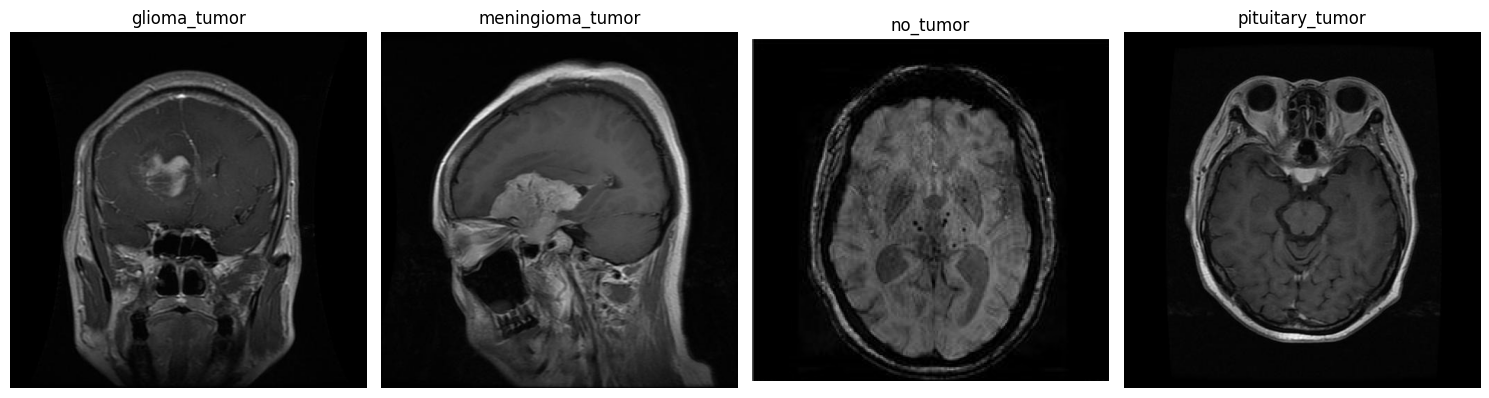

In [39]:
# Display sample images from each class
train_path = '/home/vineet/Downloads/XGBoost/brain-mri/Training'
classes = sorted([c for c in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, c))])

plt.figure(figsize=(15, 4))

for idx, class_name in enumerate(classes):
    class_path = os.path.join(train_path, class_name)
    pic = os.listdir(class_path)[0]
    image = Image.open(os.path.join(class_path, pic))
    image = np.asarray(image)
    
    plt.subplot(1, len(classes), idx + 1)
    plt.title(class_name, fontsize=12)
    plt.imshow(image, cmap='gray')
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Summary

              Class  Train  Validation  Test
0      glioma_tumor    272         554   100
1  meningioma_tumor    271         551   115
2          no_tumor    131         264   105
3   pituitary_tumor    272         555    74


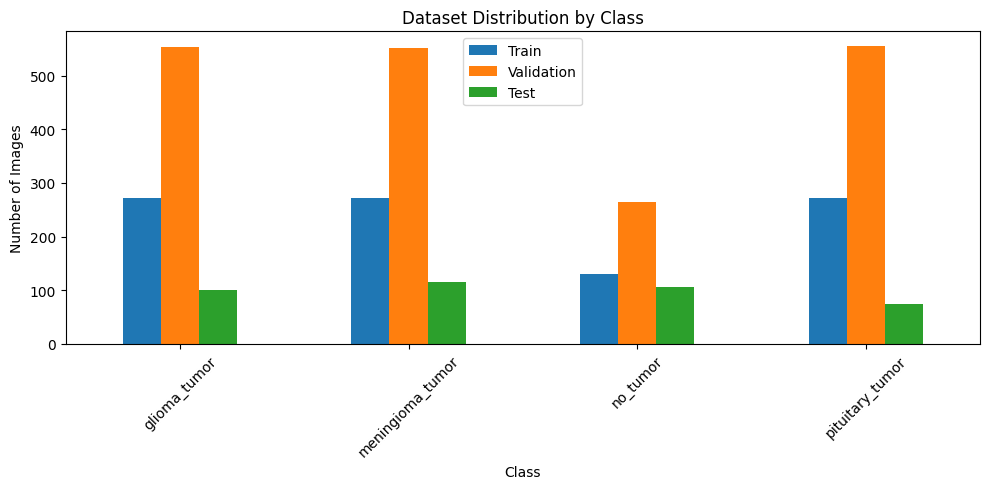

In [40]:
def get_class_counts(split):
    """Count images per class in a dataset split."""
    path = os.path.join('/home/vineet/Downloads/XGBoost/brain-mri', split)
    classes = [c for c in os.listdir(path) if os.path.isdir(os.path.join(path, c))]
    
    counts = {}
    for c in classes:
        class_path = os.path.join(path, c)
        files = [f for f in os.listdir(class_path) if not f.startswith('.')]
        counts[c] = len(files)
    
    return counts

# Create summary dataframe
train_counts = get_class_counts('Training')
val_counts = get_class_counts('Validation')
test_counts = get_class_counts('Testing')

all_categories = sorted(set(train_counts) | set(val_counts) | set(test_counts))

data_summary = pd.DataFrame({
    'Class': all_categories,
    'Train': [train_counts.get(c, 0) for c in all_categories],
    'Validation': [val_counts.get(c, 0) for c in all_categories],
    'Test': [test_counts.get(c, 0) for c in all_categories]
})

print(data_summary)

# Visualize dataset distribution
data_summary.set_index('Class').plot(kind='bar', figsize=(10, 5))
plt.title('Dataset Distribution by Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Extraction with VGG16

In [41]:
# Load pre-trained VGG16 model
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.VGG16(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Freeze the base model (transfer learning)
base_model.trainable = False

print(f"VGG16 model loaded successfully")
print(f"Total parameters: {base_model.count_params():,}")

# Extract features from all datasets
print("\nExtracting features...")
train_features = base_model.predict(train_images, verbose=0)
train_features = train_features.reshape(train_features.shape[0], -1)
del train_images

val_features = base_model.predict(val_images, verbose=0)
val_features = val_features.reshape(val_features.shape[0], -1)
del val_images

test_features = base_model.predict(test_images, verbose=0)
test_features = test_features.reshape(test_features.shape[0], -1)
del test_images

print(f"✓ Training features shape: {train_features.shape}")
print(f"✓ Validation features shape: {val_features.shape}")
print(f"✓ Testing features shape: {test_features.shape}")

VGG16 model loaded successfully
Total parameters: 14,714,688

Extracting features...
✓ Training features shape: (946, 25088)
✓ Validation features shape: (1924, 25088)
✓ Testing features shape: (394, 25088)


## Model Training

[0]	validation_0-mlogloss:1.24585	validation_1-mlogloss:1.26543
[1]	validation_0-mlogloss:1.15965	validation_1-mlogloss:1.19950
[2]	validation_0-mlogloss:1.08283	validation_1-mlogloss:1.14059
[3]	validation_0-mlogloss:1.01722	validation_1-mlogloss:1.09268
[4]	validation_0-mlogloss:0.95331	validation_1-mlogloss:1.04362
[5]	validation_0-mlogloss:0.89503	validation_1-mlogloss:0.99984
[6]	validation_0-mlogloss:0.84414	validation_1-mlogloss:0.96051
[7]	validation_0-mlogloss:0.79755	validation_1-mlogloss:0.92409
[8]	validation_0-mlogloss:0.75503	validation_1-mlogloss:0.89249
[9]	validation_0-mlogloss:0.71592	validation_1-mlogloss:0.86373
[10]	validation_0-mlogloss:0.68033	validation_1-mlogloss:0.83683
[11]	validation_0-mlogloss:0.64718	validation_1-mlogloss:0.81116
[12]	validation_0-mlogloss:0.61622	validation_1-mlogloss:0.78747
[13]	validation_0-mlogloss:0.58729	validation_1-mlogloss:0.76518
[14]	validation_0-mlogloss:0.55862	validation_1-mlogloss:0.74437
[15]	validation_0-mlogloss:0.53433	

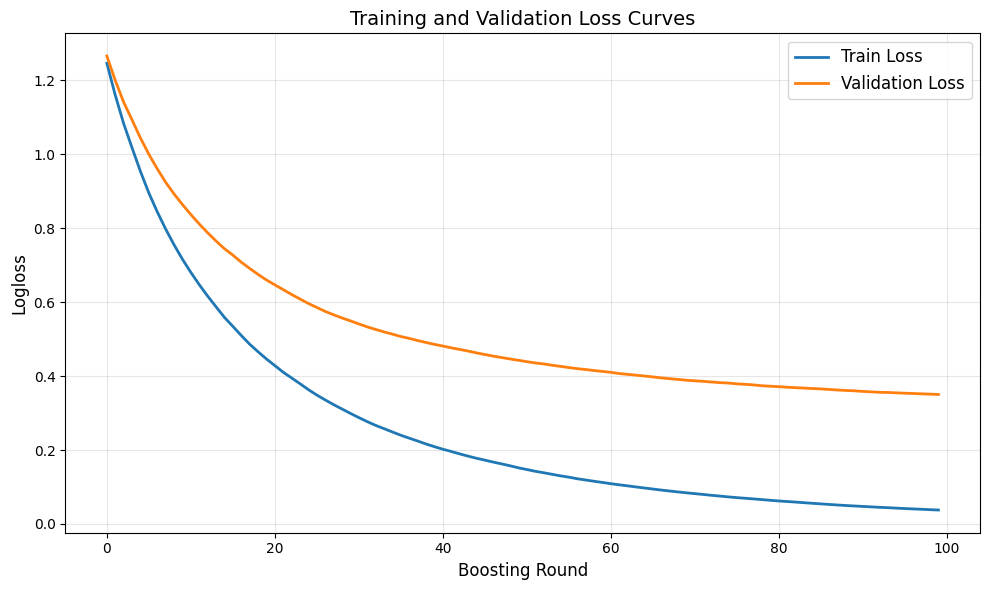

In [42]:
# Train initial model
model = XGBClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss'
)

model.fit(
    train_features,
    train_labels_encoded,
    eval_set=[
        (train_features, train_labels_encoded),
        (val_features, val_labels_encoded)
    ],
    verbose=True
)

# Get results and extract loss curves
results = model.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss = results['validation_1']['mlogloss']

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Loss', linewidth=2)
plt.plot(val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right', fontsize=12)
plt.xlabel('Boosting Round', fontsize=12)
plt.ylabel('Logloss', fontsize=12)
plt.title('Training and Validation Loss Curves', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# Calculate and display training and validation metrics
train_predictions = model.predict(train_features)
val_predictions = model.predict(val_features)

print("\n" + "="*70)
print("TRAINING PHASE RESULTS")
print("="*70)

metrics = {
    'Accuracy': (accuracy_score(train_labels_encoded, train_predictions),
                 accuracy_score(val_labels_encoded, val_predictions)),
    'Precision': (precision_score(train_labels_encoded, train_predictions, average='weighted'),
                  precision_score(val_labels_encoded, val_predictions, average='weighted')),
    'Recall': (recall_score(train_labels_encoded, train_predictions, average='weighted'),
               recall_score(val_labels_encoded, val_predictions, average='weighted')),
    'F1 Score': (f1_score(train_labels_encoded, train_predictions, average='weighted'),
                 f1_score(val_labels_encoded, val_predictions, average='weighted'))
}

print(f"\n{'Metric':<20} {'Training':<20} {'Validation':<20}")
print("-" * 70)
for metric, (train_val, val_val) in metrics.items():
    print(f"{metric:<20} {train_val:<20.4f} {val_val:<20.4f}")
print("=" * 70)


TRAINING PHASE RESULTS

Metric               Training             Validation          
----------------------------------------------------------------------
Accuracy             1.0000               0.8654              
Precision            1.0000               0.8656              
Recall               1.0000               0.8654              
F1 Score             1.0000               0.8639              


## Hyperparameter Tuning

In [44]:
# Find the best number of trees based on validation loss (minimum loss)
best_iteration = np.argmin(val_loss)
best_ntree_limit = best_iteration + 1  # +1 because iteration starts from 0

print(f"Best iteration: {best_iteration}")
print(f"Best n_estimators: {best_ntree_limit}")
print(f"Best validation loss: {val_loss[best_iteration]:.6f}")

# Retrain model with best parameters
model_final = xgboost.XGBClassifier(
    learning_rate=0.1, 
    n_estimators=best_ntree_limit,
    max_depth=3,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss'
)

model_final.fit(
    train_features, 
    train_labels_encoded,
    eval_set=[
        (train_features, train_labels_encoded),
        (val_features, val_labels_encoded)
    ],
    verbose=False
)

print("\n✓ Model retrained with best parameters!")

Best iteration: 99
Best n_estimators: 100
Best validation loss: 0.350271

✓ Model retrained with best parameters!


In [45]:
# Get class names from brain-mri test directory
test_dir = '/home/vineet/Downloads/XGBoost/brain-mri/Testing'
CLASSES = sorted([f for f in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, f))])

print(f"Classes: {CLASSES}")

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


## Test Set Evaluation


TEST SET EVALUATION
Accuracy:  0.6675
Precision: 0.6815
Recall:    0.6675
F1 Score:  0.6348



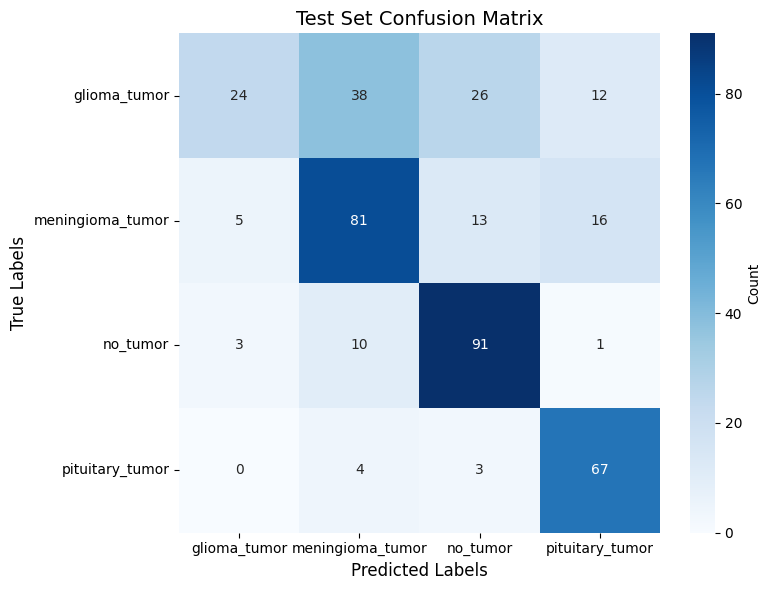

In [47]:
# Generate predictions on test set
predictions = model_final.predict(test_features)

# Evaluate performance
print("\n" + "="*70)
print("TEST SET EVALUATION")
print("="*70)
print(f"Accuracy:  {accuracy_score(test_labels_encoded, predictions):.4f}")
print(f"Precision: {precision_score(test_labels_encoded, predictions, average='weighted'):.4f}")
print(f"Recall:    {recall_score(test_labels_encoded, predictions, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(test_labels_encoded, predictions, average='weighted'):.4f}")
print("="*70 + "\n")

# Confusion Matrix visualization
cf = tf.math.confusion_matrix(labels=test_labels_encoded, predictions=predictions).numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    cbar_kws={'label': 'Count'}
)
plt.title('Test Set Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

## Data Efficiency Analysis


DATA EFFICIENCY ANALYSIS
 20% Training Data → Test Accuracy:  51.02%
 40% Training Data → Test Accuracy:  56.35%
 60% Training Data → Test Accuracy:  59.90%
 80% Training Data → Test Accuracy:  62.18%



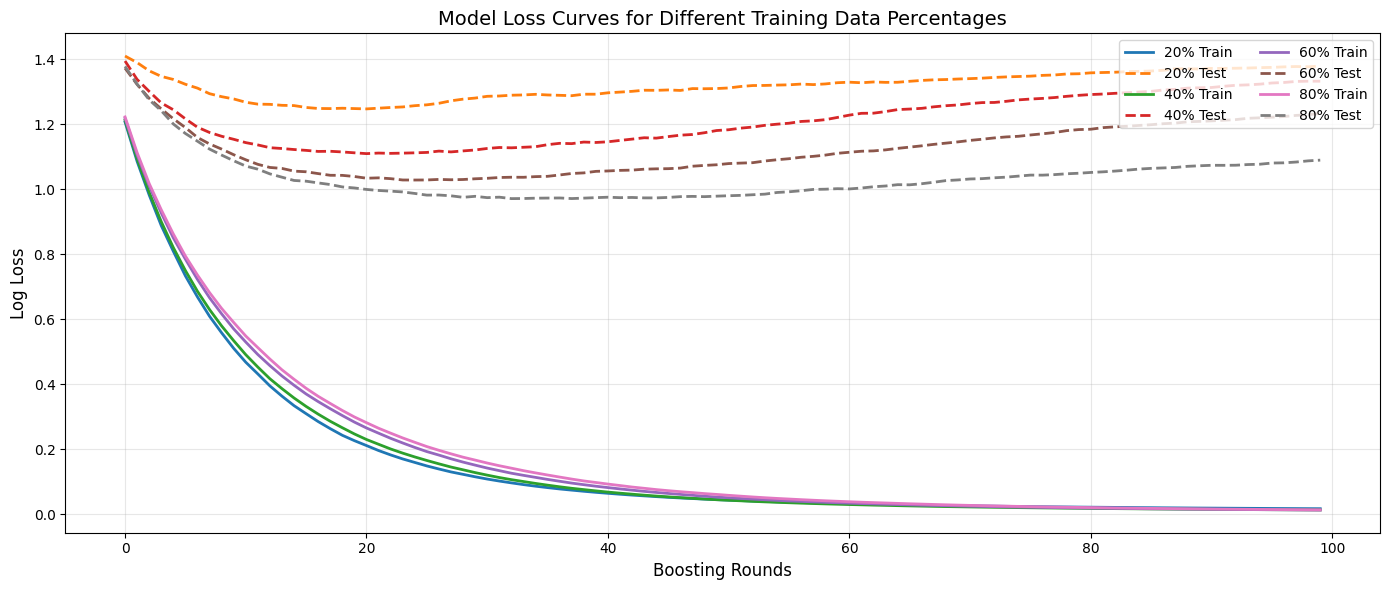

In [49]:
# Test model performance and visualize loss curves for different data percentages
percentages = [0.2, 0.4, 0.6, 0.8]
accuracy_results = []

print("\n" + "="*70)
print("DATA EFFICIENCY ANALYSIS")
print("="*70)

plt.figure(figsize=(14, 6))

for p in percentages:
    X_subset, _, y_subset, _ = train_test_split(
        train_features,
        train_labels_encoded,
        train_size=p,
        stratify=train_labels_encoded,
        random_state=42
    )
    
    model = XGBClassifier(
        objective='multi:softmax',
        num_class=4,
        eval_metric='mlogloss',
        max_depth=4,
        n_estimators=100,
        learning_rate=0.1
    )
    
    # Train with eval_set to capture loss curves
    model.fit(
        X_subset,
        y_subset,
        eval_set=[(X_subset, y_subset), (test_features, test_labels_encoded)],
        verbose=False
    )
    
    # Get predictions and accuracy
    y_pred = model.predict(test_features)
    acc = accuracy_score(test_labels_encoded, y_pred) * 100
    accuracy_results.append(acc)
    
    # Get loss curves
    results = model.evals_result()
    train_loss = results['validation_0']['mlogloss']
    test_loss = results['validation_1']['mlogloss']
    
    # Print results
    print(f"{int(p*100):>3}% Training Data → Test Accuracy: {acc:>6.2f}%")
    
    # Plot training and test loss for this percentage
    plt.plot(train_loss, label=f'{int(p*100)}% Train', linewidth=2)
    plt.plot(test_loss, linestyle='--', label=f'{int(p*100)}% Test', linewidth=2)

print("="*70 + "\n")

# Plot configuration
plt.xlabel('Boosting Rounds', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Model Loss Curves for Different Training Data Percentages', fontsize=14)
plt.legend(loc='upper right', ncol=2, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()